<div align="center">
    <h1> Xây dựng mô hình dự đoán bệnh tiểu đường</h1>
</div>

# 1. Xây dựng bài toán và thu thập dữ liệu
---
**Bài toán**
- Cần xây dựng một mô hình học máy có khả năng dự đoán xem người bệnh có bị tiểu đường hay không dựa vào các chỉ số liên quan

**Dữ liệu**
- Tập dữ liệu Diabetes-dataset.csv gồm 768 dòng dữ liệu có chứa thông tin của bệnh nhân được thu thập trên kaggle

**Mô tả tập dữ liệu thu thập được phục vụ bài toán**
- Tên Dataset: **Diabetes-dataset.csv**
- File dữ liệu chứa thông tin của 768 bệnh nhân trong quá khứ
- Mỗi dòng ứng với thông tin của một bệnh nhân, bao gồm 9 thuộc tính:
  - *Pregnancies: Thời gian thai kì*
  - *Glucose: Chỉ số glucose*
  - *BloodPressure: Huyết áp tâm trương*
  - *SkinThickness: Độ dày da*
  - *Insulin: Chỉ số isulin*
  - *BMI: Chỉ số khối của  cơ thể (kg/m^2)*
  - *DiabetesPedigreeFunction: Chức năng phả hệ bệnh tiểu đường*
  - *Age: tuổi*
  - *Outcome: kết quả cho thấy bệnh nhân có bị tiểu đường hay không (0: Không bị bệnh, 1: Bị bệnh)*
<img src = 'data.png' width='450px'>

In [375]:
#Gọi thư viện:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#--------------------------------
import warnings
warnings.filterwarnings('ignore')

In [338]:
#Đọc tập dữ liệu dataset đã thu thập được:
df = pd.read_csv('Data/Diabetes-dataset.csv')

# Hiển thị thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [339]:
#hiển thị 5 dòng dữ liệu đầu tiên
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [340]:
#hiển thị 5 dòng dữ liệu cuối cùng
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [341]:
#Lấy ngẫu nhiên 5 hồ sơ bệnh án:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
209,7,184,84,33,0,35.5,0.355,41,1
359,1,196,76,36,249,36.5,0.875,29,1
29,5,117,92,0,0,34.1,0.337,38,0
385,1,119,54,13,50,22.3,0.205,24,0
691,13,158,114,0,0,42.3,0.257,44,1


# 2. Chuẩn bị dữ liệu
## 2.1 Quan sát và khám phá tập dữ liệu
---
Quan sát các đặc trưng thống kê, các biểu đồ liên quan để hiểu dữ liệu

In [342]:
#khám phá tập dữ liệu 
#1. Quan sát Các thuộc tính số
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


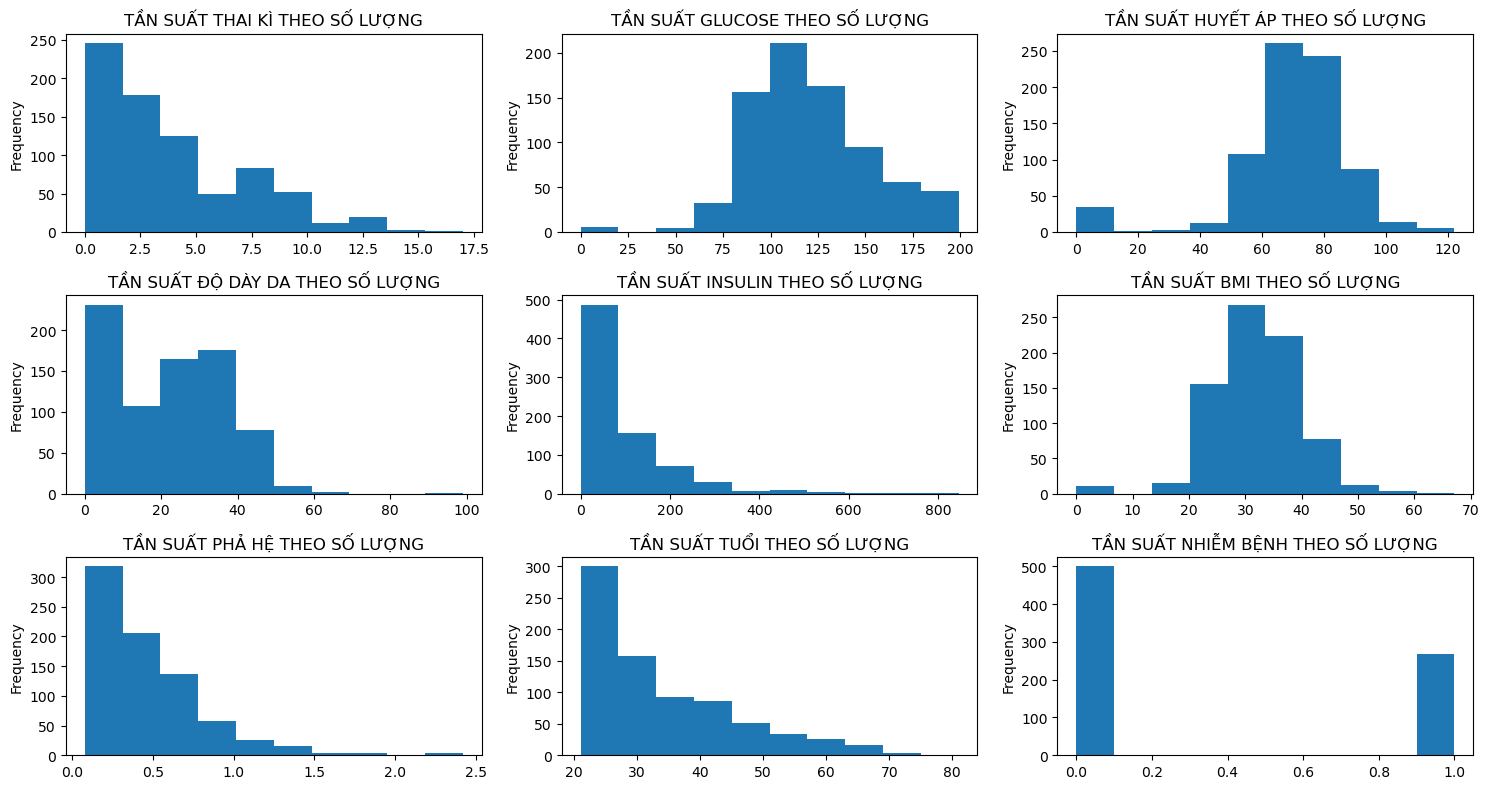

In [343]:
# Thống kê xu hướng dữ liệu
# Biểu đồ tần suất
plt.rcParams["figure.figsize"] = [15, 8]
plt.rcParams["figure.autolayout"] = True
figure, axis = plt.subplots(3, 3)

df['Pregnancies'].plot.hist(title="TẦN SUẤT THAI KÌ THEO SỐ LƯỢNG",ax=axis[0][0])
df['Glucose'].plot.hist(title="TẦN SUẤT GLUCOSE THEO SỐ LƯỢNG",ax=axis[0][1])
df['BloodPressure'].plot.hist(title="TẦN SUẤT HUYẾT ÁP THEO SỐ LƯỢNG",ax=axis[0][2])
df['SkinThickness'].plot.hist(title="TẦN SUẤT ĐỘ DÀY DA THEO SỐ LƯỢNG",ax=axis[1][0])
df['Insulin'].plot.hist(title="TẦN SUẤT INSULIN THEO SỐ LƯỢNG",ax=axis[1][1])
df['BMI'].plot.hist(title="TẦN SUẤT BMI THEO SỐ LƯỢNG",ax=axis[1][2],color=c)
df['DiabetesPedigreeFunction'].plot.hist(title="TẦN SUẤT PHẢ HỆ THEO SỐ LƯỢNG",ax=axis[2][0])
df['Age'].plot.hist(title="TẦN SUẤT TUỔI THEO SỐ LƯỢNG",ax=axis[2][1])
df['Outcome'].plot.hist(title="TẦN SUẤT NHIỄM BỆNH THEO SỐ LƯỢNG",ax=axis[2][2])
plt.show()

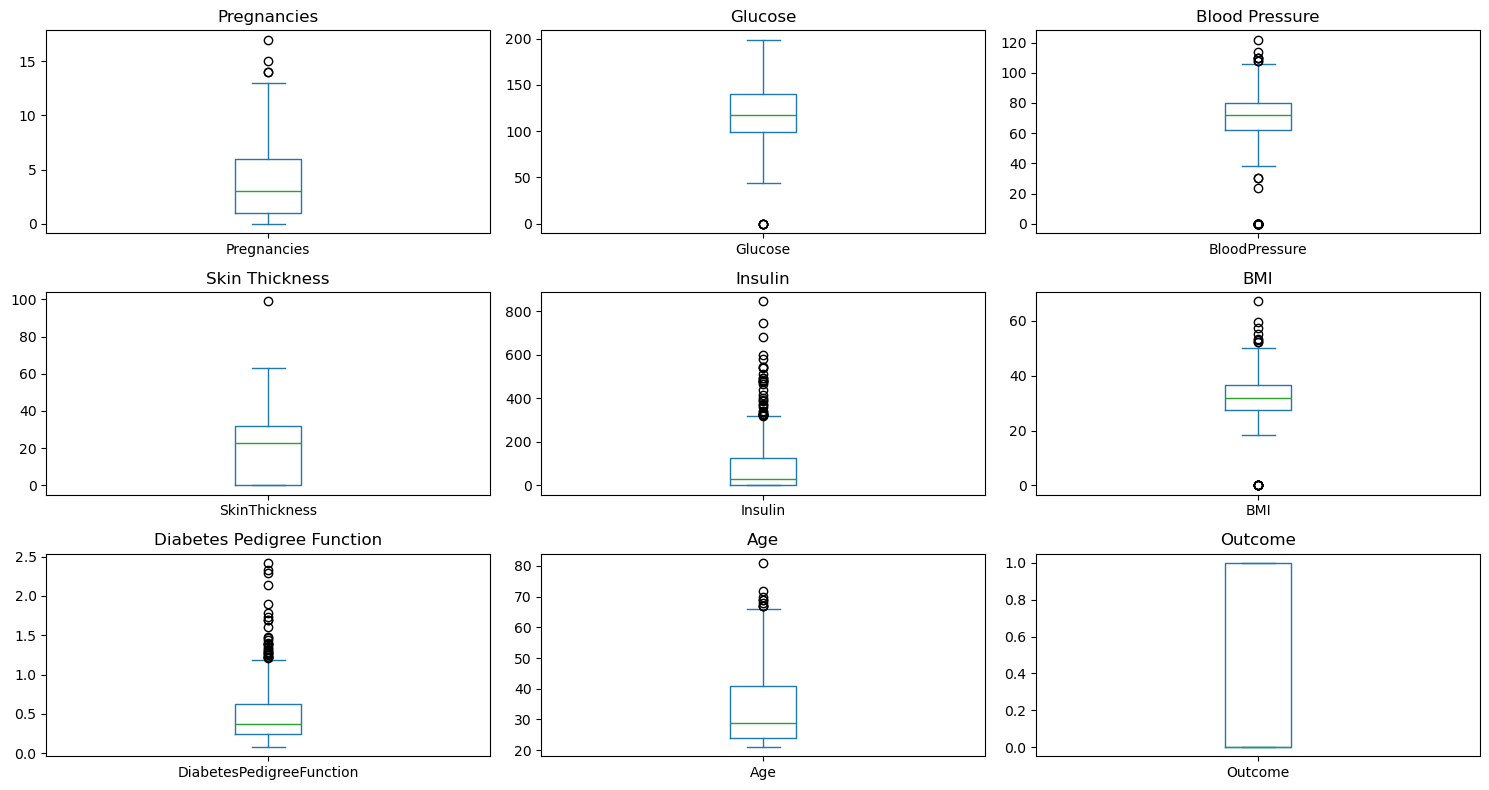

In [344]:
# Dùng biểu đồ hộp kiểm tra giá trị ngoại lai
plt.rcParams["figure.figsize"] = [15, 8]
plt.rcParams["figure.autolayout"] = True
figure, axis = plt.subplots(3, 3)
  
df['Pregnancies'].plot.box(title="Pregnancies",ax=axis[0][0])
df['Glucose'].plot.box(title="Glucose",ax=axis[0][1])
df['BloodPressure'].plot.box(title="Blood Pressure",ax=axis[0][2])
df['SkinThickness'].plot.box(title="Skin Thickness",ax=axis[1][0])
df['Insulin'].plot.box(title="Insulin",ax=axis[1][1])
df['BMI'].plot.box(title="BMI",ax=axis[1][2])
df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function",ax=axis[2][0])
df['Age'].plot.box(title="Age",ax=axis[2][1])
df['Outcome'].plot.box(title="Outcome",ax=axis[2][2])
plt.show()

In [345]:
# Hệ số tương quan của dữ liệu
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


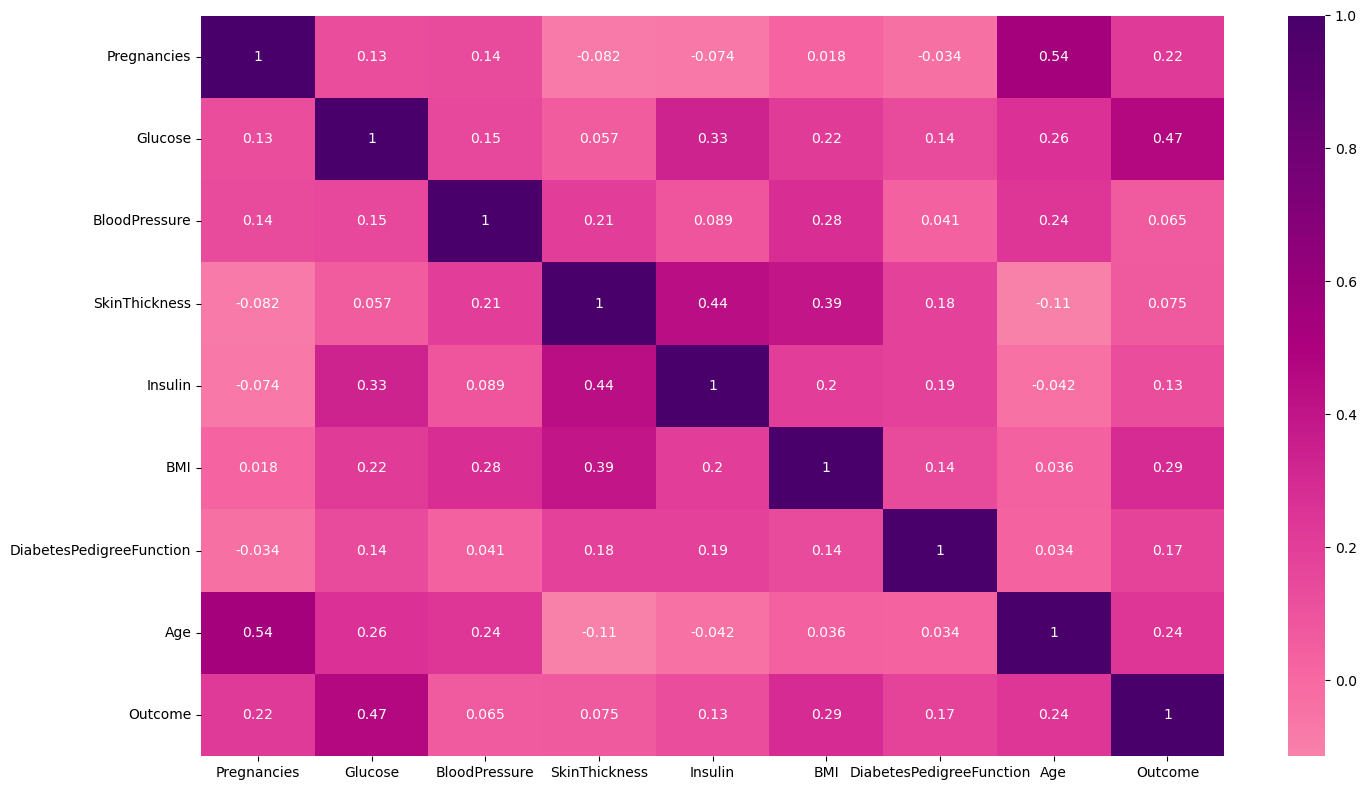

In [346]:
# Trực quan bằng biểu đồ
dataplot = sns.heatmap(df.corr(), cmap='RdPu', annot=True, center=0)

In [347]:
# Loại bỏ trường dữ liệu thừa qua so sánh hệ số tương quan
columns = df.columns

for i in range(len(columns)-1):
    for j in range(i+1,len(columns)):
        if 0.5<=df[columns[i]].corr(df[columns[j]]):
            print("Ta có thể loại bỏ "+str(columns[i])+" hoặc "+str(columns[j]))

Ta có thể loại bỏ Pregnancies hoặc Age


In [348]:
# loại bỏ cột thai kì
df.drop(['Pregnancies'], axis=1, inplace=True)

In [349]:
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101,76,48,180,32.9,0.171,63,0
764,122,70,27,0,36.8,0.340,27,0
765,121,72,23,112,26.2,0.245,30,0
766,126,60,0,0,30.1,0.349,47,1


## 2.2 Phát hiện và xử lí dữ liệu thiếu trong dataset
---
Kiểm tra dữ liệu thiếu

In [350]:
# Kiểm tra dữ liệu thiếu trong Dataset
df.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Không có dòng dữ liệu nào bị thiếu**

## 2.3 Xử lý giá trị ngoại lai
---

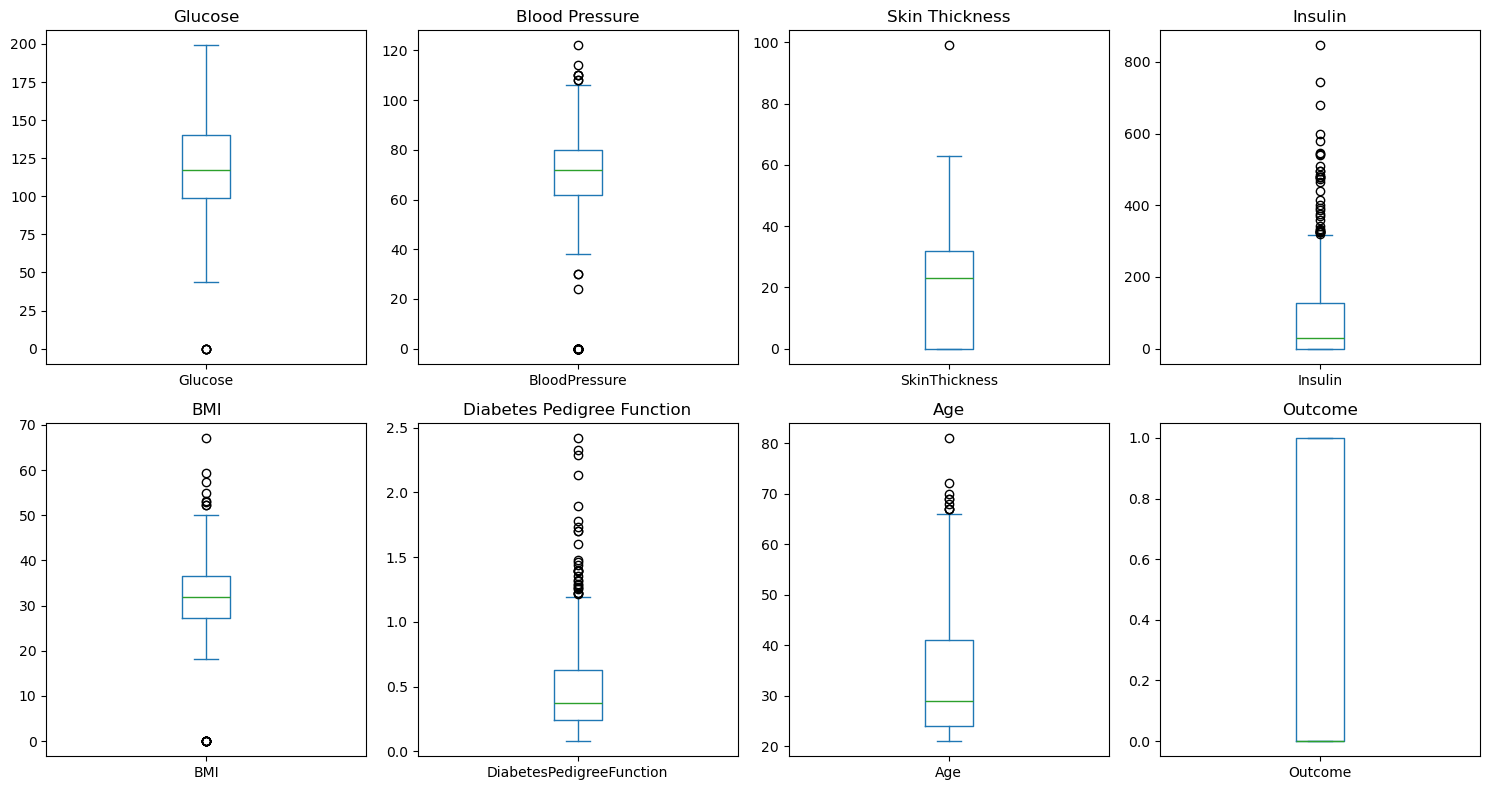

In [351]:
# Dùng biểu đồ hộp kiểm tra giá trị ngoại lai
plt.rcParams["figure.figsize"] = [15, 8]
plt.rcParams["figure.autolayout"] = True
figure, axis = plt.subplots(2, 4)
  
df['Glucose'].plot.box(title="Glucose",ax=axis[0][0])
df['BloodPressure'].plot.box(title="Blood Pressure",ax=axis[0][1])
df['SkinThickness'].plot.box(title="Skin Thickness",ax=axis[0][2])
df['Insulin'].plot.box(title="Insulin",ax=axis[0][3])
df['BMI'].plot.box(title="BMI",ax=axis[1][0])
df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function",ax=axis[1][1])
df['Age'].plot.box(title="Age",ax=axis[1][2])
df['Outcome'].plot.box(title="Outcome",ax=axis[1][3])
plt.show()

In [352]:
# Xử lý ngoại lai cho Glucose
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['Glucose']<=lower_limit,'Glucose'] = np.mean(df['Glucose'])
df.loc[df['Glucose']>upper_limit, 'Glucose'] = np.mean(df['Glucose'])

In [353]:
# Xử lý ngoại lai cho BloodPressure
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['BloodPressure']<=lower_limit,'BloodPressure'] = np.mean(df['BloodPressure'])
df.loc[df['BloodPressure']>upper_limit, 'BloodPressure'] = np.mean(df['BloodPressure'])

In [354]:
# Xử lý ngoại lai cho SkinThickness
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['SkinThickness']<=lower_limit,'SkinThickness'] = np.mean(df['SkinThickness'])
df.loc[df['SkinThickness']>upper_limit, 'SkinThickness'] = np.mean(df['SkinThickness'])

In [355]:
# Xử lý ngoại lai cho Insulin
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['Insulin']<=lower_limit,'Insulin'] = np.mean(df['Insulin'])
df.loc[df['Insulin']>upper_limit, 'Insulin'] = np.mean(df['Insulin'])

In [356]:
# Xử lý ngoại lai cho BMI
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['BMI']<=lower_limit,'BMI'] = np.mean(df['BMI'])
df.loc[df['BMI']>upper_limit, 'BMI'] = np.mean(df['BMI'])

In [357]:
# Xử lý ngoại lai cho DiabetesPedigreeFunction
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['DiabetesPedigreeFunction']<=lower_limit,'DiabetesPedigreeFunction'] = np.mean(df['DiabetesPedigreeFunction'])
df.loc[df['DiabetesPedigreeFunction']>upper_limit, 'DiabetesPedigreeFunction'] = np.mean(df['DiabetesPedigreeFunction'])

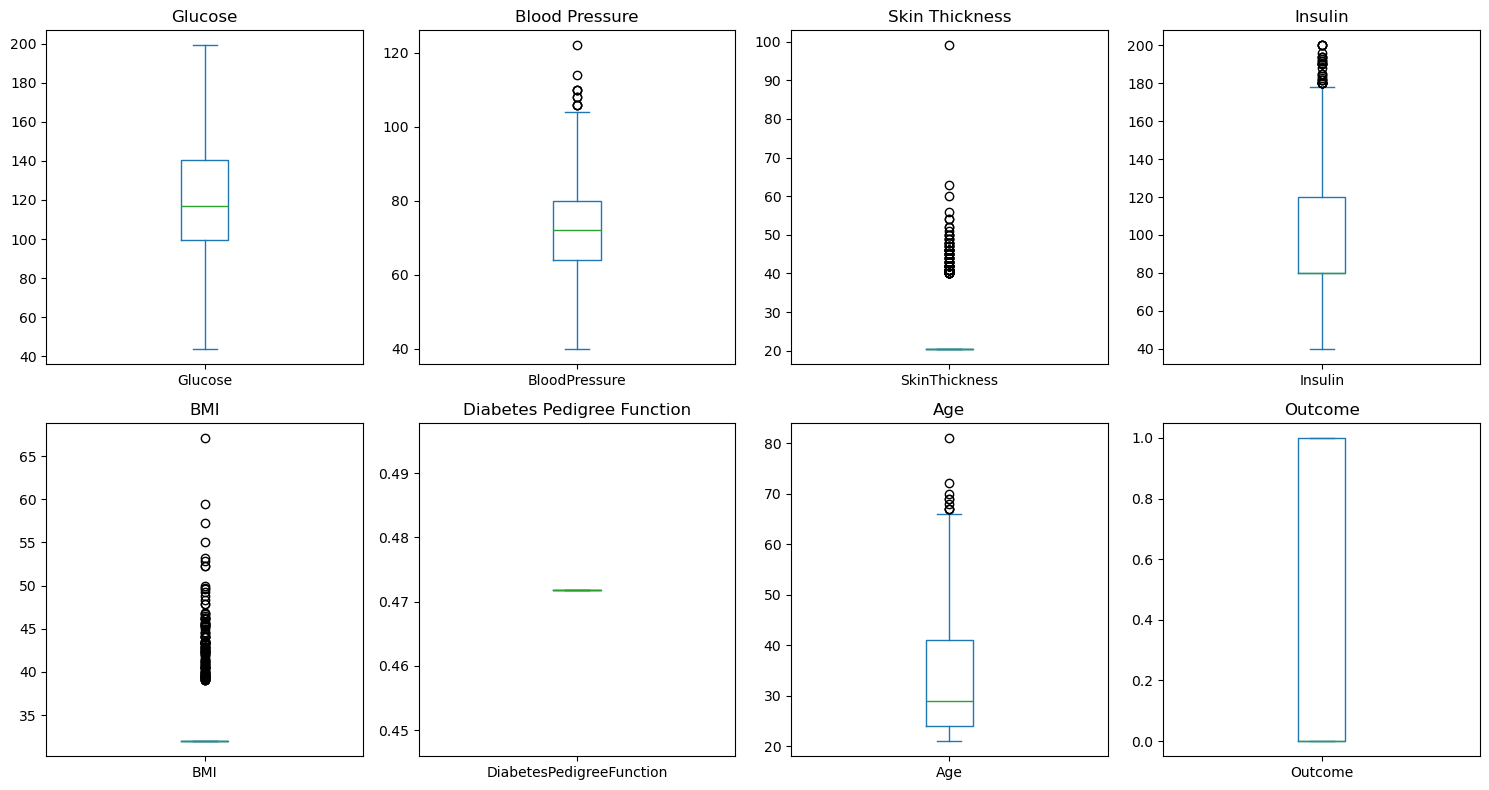

In [358]:
# Kiểm tra lại kết quả
# Dùng biểu đồ hộp kiểm tra giá trị ngoại lai
plt.rcParams["figure.figsize"] = [15, 8]
plt.rcParams["figure.autolayout"] = True
figure, axis = plt.subplots(2, 4)
  
df['Glucose'].plot.box(title="Glucose",ax=axis[0][0])
df['BloodPressure'].plot.box(title="Blood Pressure",ax=axis[0][1])
df['SkinThickness'].plot.box(title="Skin Thickness",ax=axis[0][2])
df['Insulin'].plot.box(title="Insulin",ax=axis[0][3])
df['BMI'].plot.box(title="BMI",ax=axis[1][0])
df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function",ax=axis[1][1])
df['Age'].plot.box(title="Age",ax=axis[1][2])
df['Outcome'].plot.box(title="Outcome",ax=axis[1][3])
plt.show()

In [359]:
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148.0,72.0,20.536458,79.799479,31.992578,0.471876,50,1
1,85.0,66.0,20.536458,79.799479,31.992578,0.471876,31,0
2,183.0,64.0,20.536458,79.799479,31.992578,0.471876,32,1
3,89.0,66.0,20.536458,94.000000,31.992578,0.471876,21,0
4,137.0,40.0,20.536458,168.000000,43.100000,0.471876,33,1
...,...,...,...,...,...,...,...,...
763,101.0,76.0,48.000000,180.000000,31.992578,0.471876,63,0
764,122.0,70.0,20.536458,79.799479,31.992578,0.471876,27,0
765,121.0,72.0,20.536458,112.000000,31.992578,0.471876,30,0
766,126.0,60.0,20.536458,79.799479,31.992578,0.471876,47,1


In [360]:
# Lưu dữ liệu đã được xử lý
df.to_csv('Data/Diabetes-dataset_OK.csv', index=None)

## 2.4 Trích xuất biến phụ thuộc và biến độc lập
---

In [226]:
#Lấy giá trị biến độc lập: X
X = df.loc[:,['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]

print('Kích thước biến độc lập X:',X.shape)
X

Kích thước biến độc lập X: (768, 7)


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148.0,72.0,20.536458,79.799479,31.992578,0.471876,50.000000
1,85.0,66.0,20.536458,79.799479,31.992578,0.471876,33.240885
2,183.0,64.0,20.536458,79.799479,31.992578,0.471876,33.240885
3,89.0,66.0,20.536458,94.000000,31.992578,0.471876,33.240885
4,137.0,40.0,20.536458,168.000000,43.100000,0.471876,33.240885
...,...,...,...,...,...,...,...
763,101.0,76.0,48.000000,180.000000,31.992578,0.471876,63.000000
764,122.0,70.0,20.536458,79.799479,31.992578,0.471876,33.240885
765,121.0,72.0,20.536458,112.000000,31.992578,0.471876,33.240885
766,126.0,60.0,20.536458,79.799479,31.992578,0.471876,47.000000


In [227]:
#Lấy giá trị biến phụ thuộc: y
y=df.loc[:,'Outcome']

print('Kích thước biến phụ thuộc y:',y.shape)
y

Kích thước biến phụ thuộc y: (768,)


0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

### Chuẩn hóa dữ liệu
---

In [228]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #tính toán trung bình và độ lệch chuẩn cho từng đặc trưng.
X_scaled = pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

In [229]:
X_scaled

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.865276,-0.038891,-0.347140,-0.511877,-0.401230,-1.110223e-16,1.453588
1,-1.205989,-0.550746,-0.347140,-0.511877,-0.401230,-1.110223e-16,-0.520186
2,2.015979,-0.721365,-0.347140,-0.511877,-0.401230,-1.110223e-16,-0.520186
3,-1.074480,-0.550746,-0.347140,-0.073464,-0.401230,-1.110223e-16,-0.520186
4,0.503626,-2.768789,-0.347140,2.211139,2.003181,-1.110223e-16,-0.520186
...,...,...,...,...,...,...,...
763,-0.679954,0.302347,2.976878,2.581615,-0.401230,-1.110223e-16,2.984640
764,0.010468,-0.209509,-0.347140,-0.511877,-0.401230,-1.110223e-16,-0.520186
765,-0.022409,-0.038891,-0.347140,0.482250,-0.401230,-1.110223e-16,-0.520186
766,0.141977,-1.062602,-0.347140,-0.511877,-0.401230,-1.110223e-16,1.100269


## 2.5 Tách tập dữu liệu Train, Test
---

In [230]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, #Biến độc lập X tách thành (X_train; X_Test)
                                                    y, #Biến phụ thuộc y tách thành (y_train; y_test)
                                                    train_size=0.8, #Tỷ lệ tách: train = 0.8 (80%)
                                                    shuffle=True)   #Lấy các mẫu ngẫu nghiên 
print('Kích thước tập dữ liệu ban đầu:', len(X))
print('1.Kích thước tập Training:', X_train.shape)
print('2.Kích thước tập Test:', X_test.shape)


Kích thước tập dữ liệu ban đầu: 768
1.Kích thước tập Training: (614, 7)
2.Kích thước tập Test: (154, 7)


In [231]:
#Dữ liệu X_train
print('Kích thước biến độc lập X_train:',X_train.shape)
X_train

Kích thước biến độc lập X_train: (614, 7)


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
304,150.000000,76.0,20.536458,79.799479,31.992578,0.471876,33.240885
291,107.000000,62.0,20.536458,74.000000,31.992578,0.471876,33.240885
352,61.000000,82.0,20.536458,79.799479,31.992578,0.471876,46.000000
88,136.000000,70.0,20.536458,110.000000,31.992578,0.471876,43.000000
75,120.894531,48.0,20.536458,79.799479,31.992578,0.471876,33.240885
...,...,...,...,...,...,...,...
561,198.000000,66.0,20.536458,119.834110,41.300000,0.471876,33.240885
160,151.000000,90.0,20.536458,79.799479,31.992578,0.471876,33.240885
637,94.000000,76.0,20.536458,66.000000,31.992578,0.471876,33.240885
549,189.000000,110.0,20.536458,79.799479,31.992578,0.471876,33.240885


In [232]:
#Dữ liệu y_train
print('Kích thước biến phụ thuộc y_train:',y_train.shape)
y_train

Kích thước biến phụ thuộc y_train: (614,)


304    0
291    1
352    0
88     1
75     0
      ..
561    1
160    0
637    0
549    0
346    0
Name: Outcome, Length: 614, dtype: int64

# 3.Lựa chọn mô hình học máy & huấn luyện mô hình
---


### Logistic Regression

In [233]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=16)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,16
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [234]:
y_pred = lr.predict(X_test)

In [236]:
#Import module accuracy_score trong thư viện sklearn.metrics để đánh giá độ chính xác:
from sklearn.metrics import accuracy_score

#1. Đếm tổng số mẫu dự đoán đúng trên tập Test: normalize=False
acc_test_num = accuracy_score(y_test, y_pred, normalize=False)
print('Tổng số mẫu model dự đoán đúng trên tập Test:', acc_test_num,'/', len(y_test))
print('Tổng số mẫu model dự đoán sai trên tập Test:',  len(y_test) - acc_test_num,'/', len(y_test))


Tổng số mẫu model dự đoán đúng trên tập Test: 115.0 / 154
Tổng số mẫu model dự đoán sai trên tập Test: 39.0 / 154


In [237]:
#2.Độ chính xác (Accuracy) theo tỷ lệ % 
#(số mẫu dự đoán đúng/tổng số mẫu của tập test): normalize=True
acc_test = accuracy_score(y_test, y_pred, normalize=True)
print('Độ chính xác của model trên tập Test:', acc_test)
print('Độ chính xác  (%)của model trên tập Test:', round(acc_test*100,2))


Độ chính xác của model trên tập Test: 0.7467532467532467
Độ chính xác  (%)của model trên tập Test: 74.68


[[87 10]
 [29 28]]


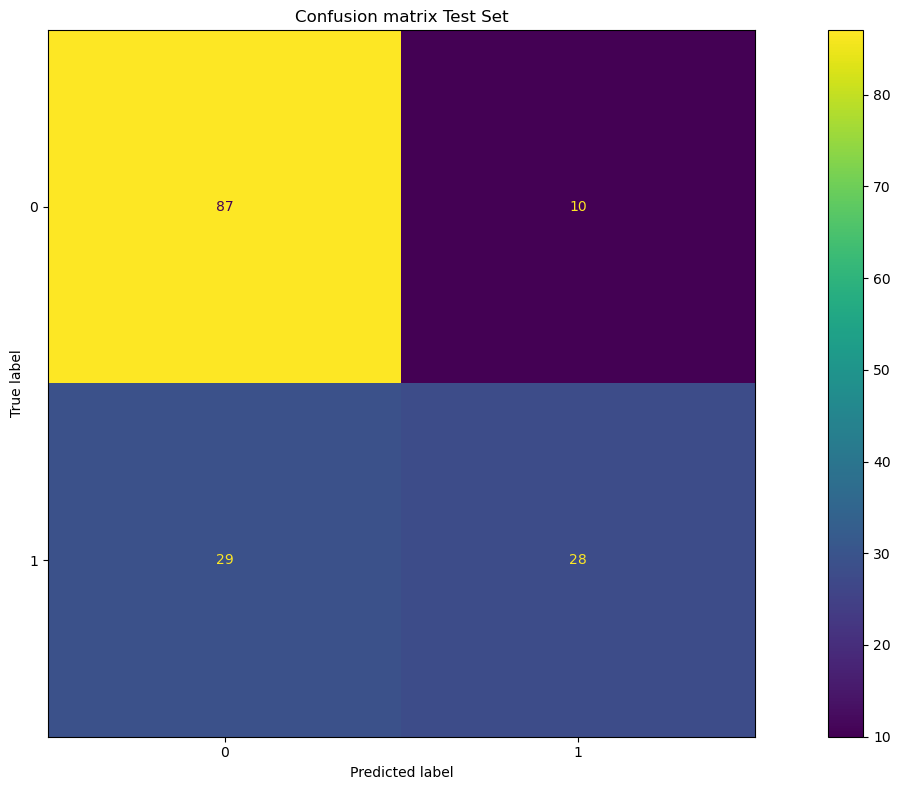

In [238]:
#3.Sử dụng ma trận confussion matrix kiểm tra kết quả:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Tính ma trận confusion matrix:
cnf_matrix= confusion_matrix(y_test,y_pred)

#Hiển thị ma trận: 
print(cnf_matrix)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion matrix Test Set')
plt.show()

### Naive Bayes

In [239]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_nb_pred = gnb.predict(X_test)

In [240]:
#Kết quả dự đoán của mô hình trên tập test:
print('Số lượng mẫu mô hình dự đoán:', len(y_nb_pred))
print(y_nb_pred)

Số lượng mẫu mô hình dự đoán: 154
[0 0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0
 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1
 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0
 1 1 0 0 0 0]


In [241]:
#Import module accuracy_score trong thư viện sklearn.metrics để đánh giá độ chính xác:
from sklearn.metrics import accuracy_score

#1. Đếm tổng số mẫu dự đoán đúng trên tập Test: normalize=False
acc_test_num2 = accuracy_score(y_test, y_nb_pred, normalize=False)
print('Tổng số mẫu model dự đoán đúng trên tập Test:', acc_test_num2,'/', len(y_test))
print('Tổng số mẫu model dự đoán sai trên tập Test:',  len(y_test) - acc_test_num2,'/', len(y_test))

Tổng số mẫu model dự đoán đúng trên tập Test: 112.0 / 154
Tổng số mẫu model dự đoán sai trên tập Test: 42.0 / 154


In [242]:
#2.Độ chính xác (Accuracy) theo tỷ lệ % 
#(số mẫu dự đoán đúng/tổng số mẫu của tập test): normalize=True
acc_test2 = accuracy_score(y_test, y_nb_pred, normalize=True)
print('Độ chính xác của model trên tập Test:', acc_test2)
print('Độ chính xác  (%)của model trên tập Test:', round(acc_test2*100,2))

Độ chính xác của model trên tập Test: 0.7272727272727273
Độ chính xác  (%)của model trên tập Test: 72.73


[[84 13]
 [29 28]]


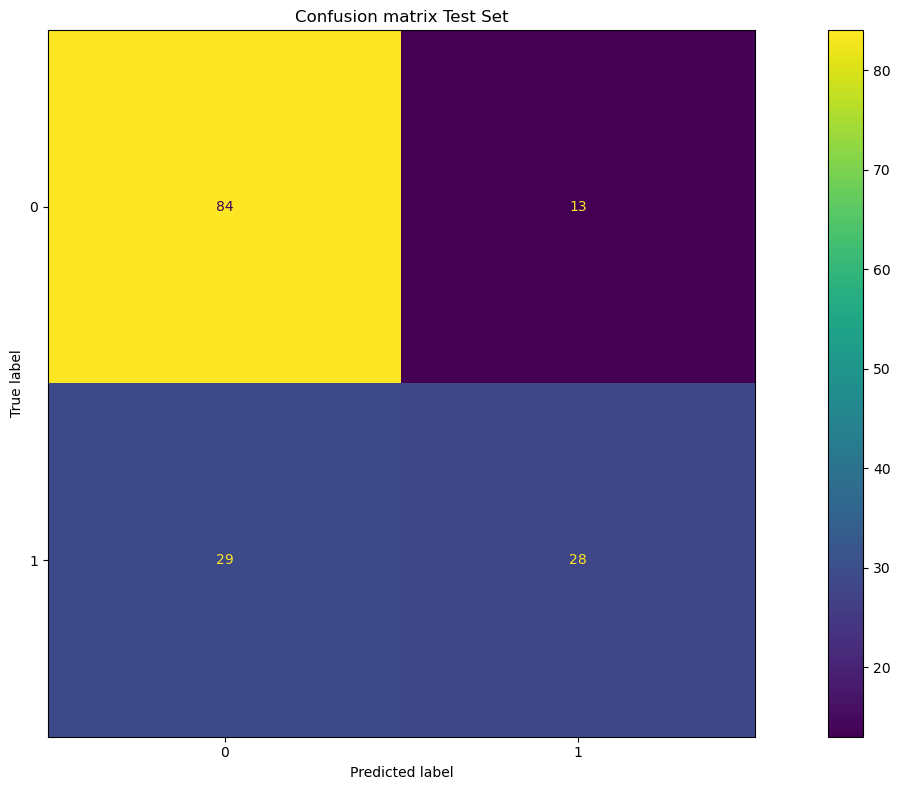

In [243]:
#3.Sử dụng ma trận confussion matrix kiểm tra kết quả:
#Tính ma trận confusion matrix:
cnf_matrix2= confusion_matrix(y_test,y_nb_pred)

#Hiển thị ma trận: 
print(cnf_matrix2)
ConfusionMatrixDisplay.from_predictions(y_test, y_nb_pred)
plt.title('Confusion matrix Test Set')
plt.show()

### Support Vector Classifier

In [308]:
from sklearn import svm
svm = svm.SVC(kernel='poly') 
svm.fit(X_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [309]:
y_svm_pred = svm.predict(X_test)

In [310]:
#Import module accuracy_score trong thư viện sklearn.metrics để đánh giá độ chính xác:
from sklearn.metrics import accuracy_score

#1. Đếm tổng số mẫu dự đoán đúng trên tập Test: normalize=False
acc_test_num3 = accuracy_score(y_test, y_svm_pred, normalize=False)
print('Tổng số mẫu model dự đoán đúng trên tập Test:', acc_test_num3,'/', len(y_test))
print('Tổng số mẫu model dự đoán sai trên tập Test:',  len(y_test) - acc_test_num3,'/', len(y_test))

Tổng số mẫu model dự đoán đúng trên tập Test: 116.0 / 154
Tổng số mẫu model dự đoán sai trên tập Test: 38.0 / 154


In [311]:
#2.Độ chính xác (Accuracy) theo tỷ lệ % 
#(số mẫu dự đoán đúng/tổng số mẫu của tập test): normalize=True
acc_test3 = accuracy_score(y_test, y_svm_pred, normalize=True)
print('Độ chính xác của model trên tập Test:', acc_test3)
print('Độ chính xác  (%)của model trên tập Test:', round(acc_test3*100,2))

Độ chính xác của model trên tập Test: 0.7532467532467533
Độ chính xác  (%)của model trên tập Test: 75.32


[[91  6]
 [32 25]]


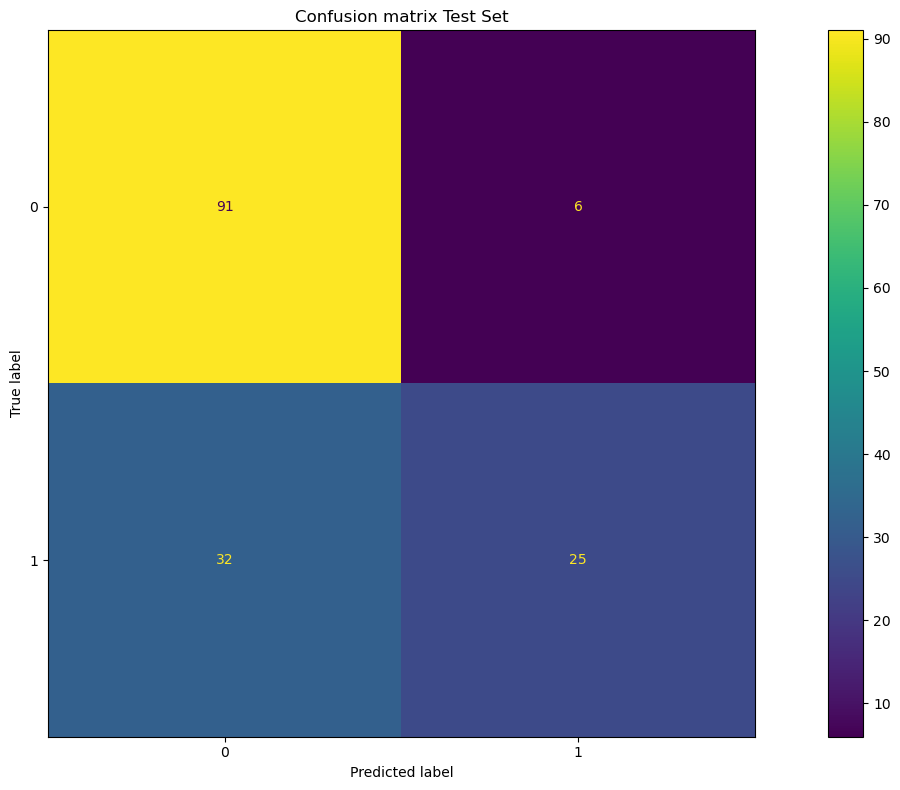

In [312]:
#3.Sử dụng ma trận confussion matrix kiểm tra kết quả:
#Tính ma trận confusion matrix:
cnf_matrix3= confusion_matrix(y_test,y_svm_pred)

#Hiển thị ma trận: 
print(cnf_matrix3)
ConfusionMatrixDisplay.from_predictions(y_test, y_svm_pred)
plt.title('Confusion matrix Test Set')
plt.show()

### KNN

In [249]:
#Gọi thư viện sklearn với thuật toán phân lớp KNN
from sklearn.neighbors import KNeighborsClassifier

#Khai báo model KNN sử dụng các tham số mặc định
KNN = KNeighborsClassifier(n_neighbors=11,
                                    weights='distance',
                                    p=1)

#Hiển thị danh sách tham số: 
KNN.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 11,
 'p': 1,
 'weights': 'distance'}

In [250]:

KNN.fit(X_train, y_train)

,n_neighbors,11
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [251]:
y_KNN_pred = KNN.predict(X_test)

In [252]:
#1. Đếm tổng số mẫu dự đoán đúng trên tập Test: normalize=False
acc_test_num4 = accuracy_score(y_test, y_KNN_pred, normalize=False)
print('Tổng số mẫu model dự đoán đúng trên tập Test:', acc_test_num4,'/', len(y_test))
print('Tổng số mẫu model dự đoán sai trên tập Test:',  len(y_test) - acc_test_num4,'/', len(y_test))

Tổng số mẫu model dự đoán đúng trên tập Test: 114.0 / 154
Tổng số mẫu model dự đoán sai trên tập Test: 40.0 / 154


In [253]:
#2.Độ chính xác (Accuracy) theo tỷ lệ % 
#(số mẫu dự đoán đúng/tổng số mẫu của tập test): normalize=True
acc_test4 = accuracy_score(y_test, y_KNN_pred, normalize=True)
print('Độ chính xác của model trên tập Test:', acc_test4)
print('Độ chính xác  (%)của model trên tập Test:', round(acc_test4*100,2))

Độ chính xác của model trên tập Test: 0.7402597402597403
Độ chính xác  (%)của model trên tập Test: 74.03


[[85 12]
 [28 29]]


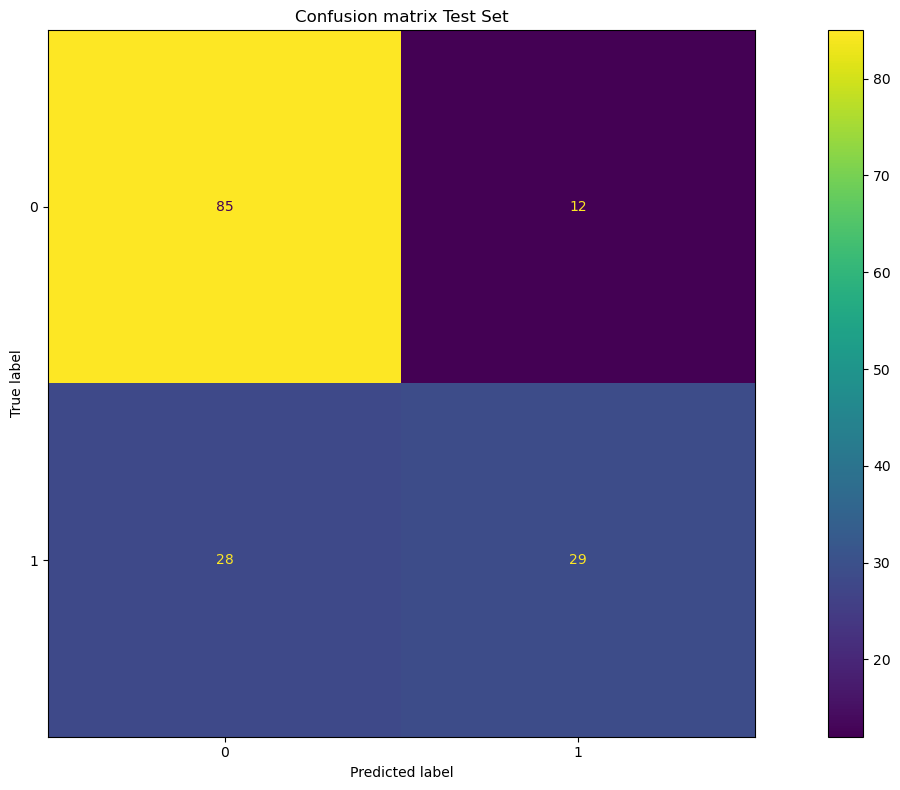

In [254]:
#3.Sử dụng ma trận confussion matrix kiểm tra kết quả:
#Tính ma trận confusion matrix:
cnf_matrix4= confusion_matrix(y_test,y_KNN_pred)

#Hiển thị ma trận: 
print(cnf_matrix4)
ConfusionMatrixDisplay.from_predictions(y_test, y_KNN_pred)
plt.title('Confusion matrix Test Set')
plt.show()

# 4. Nâng cao độ chính xác
---


In [289]:
# Tạo hàm tìm tham số tốt nhất
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

def best_svm_params(X_train, y_train):
    # Khởi tạo mô hình SVM
    svm = SVC()

    # Tập hợp các tham số cần thử
    param_grid = {
        'C': [0.1, 1, 10, 100],          # hệ số phạt
        'gamma': [1, 0.1, 0.01, 0.001],  # hệ số kernel
        'kernel': ['rbf', 'linear']      # loại kernel
    }

    # GridSearchCV để tìm tham số tốt nhất
    grid = GridSearchCV(svm, param_grid, refit=True, cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)

    print("Best Parameters:", grid.best_params_)
    print("Best Score:", grid.best_score_)

    # Trả về mô hình đã huấn luyện với tham số tốt nhất
    return grid.best_estimator_


In [290]:
best_svm_params(X_train, y_train)

Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Best Score: 0.7524323603891777


,C,0.1
,kernel,'linear'
,degree,3
,gamma,1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [369]:
from sklearn import svm
svm = svm.SVC(kernel='linear',
              gamma=1,
              C=0.1) 
svm.fit(X_train, y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [370]:
y_svm_pred = svm.predict(X_test)

In [371]:
#Độ chính xác (Accuracy) theo tỷ lệ % 
#(số mẫu dự đoán đúng/tổng số mẫu của tập test): normalize=True
acc_test3 = accuracy_score(y_test, y_svm_pred, normalize=True)
print('Độ chính xác của model trên tập Test:', acc_test3)
print('Độ chính xác  (%)của model trên tập Test:', round(acc_test3*100,2))

Độ chính xác của model trên tập Test: 0.7532467532467533
Độ chính xác  (%)của model trên tập Test: 75.32


In [372]:
df_copy = pd.read_csv('Data/Diabetes-dataset_OK.csv')
df_copy

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148.0,72.0,20.536458,79.799479,31.992578,0.471876,50,1
1,85.0,66.0,20.536458,79.799479,31.992578,0.471876,31,0
2,183.0,64.0,20.536458,79.799479,31.992578,0.471876,32,1
3,89.0,66.0,20.536458,94.000000,31.992578,0.471876,21,0
4,137.0,40.0,20.536458,168.000000,43.100000,0.471876,33,1
...,...,...,...,...,...,...,...,...
763,101.0,76.0,48.000000,180.000000,31.992578,0.471876,63,0
764,122.0,70.0,20.536458,79.799479,31.992578,0.471876,27,0
765,121.0,72.0,20.536458,112.000000,31.992578,0.471876,30,0
766,126.0,60.0,20.536458,79.799479,31.992578,0.471876,47,1


# 5. Dự đoán với mô hình xây dựng được
---
Giả sử bệnh nhân số 1 có các thuộc tính liên quan như sau:

   - Tuổi (Age)               : 69
   - Glucose                  :140
   - SkinThickness            : 32
   - Huyết áp (Blood_pressure): 70
   - Insulin                  : 90
   - BMI                      : 30
   - DiabetesPedigreeFunction : 0.65

In [377]:
# Khai báo dữ liệu cho bệnh nhân 1
A = 69
G = 140
S = 32
B = 70
I = 90
BMI = 30
D = 0.65
benhnhan_1 = np.array([[A,G,S,B,I,BMI,D]])
print('Hồ sơ của bệnh nhân số 1:', benhnhan_1)

Hồ sơ của bệnh nhân số 1: [[ 69.   140.    32.    70.    90.    30.     0.65]]


In [378]:
#Sử dụng mô hình để dự đoán cho bệnh nhân 1
pre_1 = svm.predict(benhnhan_1)
print(pre_1)
if pre_1 == 0:
    print('Doctor AI said: Chúc mừng, sức khỏe bạn bạn bình thường!')
else:
    print('Doctor AI said: Nguy rồi, bạn đã bị mắc tiểu đường')

[1]
Doctor AI said: Nguy rồi, bạn đã bị mắc tiểu đường
